# Retail Demand Forecasting — Model Development

## Objective

The aim of this notebook is to build and compare forecasting models for the five selected products.

I will:

- prepare the weekly demand series for modelling
- create a time-based train/test split
- build a simple baseline forecast
- evaluate forecast accuracy using consistent metrics
- compare baseline and more advanced forecasting approaches
- identify the most suitable model for each product

In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PROCESSED = Path("../data/processed")
FILE_PATH = DATA_PROCESSED / "weekly_forecast_data.csv"

forecast_data = pd.read_csv(
    FILE_PATH,
    parse_dates=["invoice_date"]
)

forecast_data.head()

,invoice_date,stock_code,description,weekly_demand,active_days,complete_week
0,2009-12-06,21212,PACK OF 72 RETROSPOT CAKE CASES,1528,6,True
1,2009-12-13,21212,PACK OF 72 RETROSPOT CAKE CASES,1121,6,True
2,2009-12-20,21212,PACK OF 72 RETROSPOT CAKE CASES,1591,6,True
3,2009-12-27,21212,PACK OF 72 RETROSPOT CAKE CASES,764,3,False
4,2010-01-03,21212,PACK OF 72 RETROSPOT CAKE CASES,0,0,False


In [40]:
print("Rows and columns:", forecast_data.shape)

print("\nData types:")
print(forecast_data.dtypes)

print("\nProducts:")
print(forecast_data["stock_code"].unique())

Rows and columns: (530, 6)

Data types:
invoice_date     datetime64[us]
stock_code                  str
description                 str
weekly_demand             int64
active_days               int64
complete_week              bool
dtype: object

Products:
<StringArray>
['21212', '84077', '84879', '85099B', '85123A']
Length: 5, dtype: str


## Train and Test Split

Forecasting requires a time-based split rather than a random train/test split.

I will use the earlier weeks for model training and reserve the final 12 weeks as the test period. This simulates a real forecasting situation where only historical demand is available when predicting future demand.

The `complete_week` flag will be retained so incomplete trading weeks can still be identified during model evaluation.

In [41]:
all_weeks = sorted(
    forecast_data["invoice_date"].unique()
)

test_weeks = all_weeks[-12:]

print("Test period:")
print(test_weeks[0], "to", test_weeks[-1])

Test period:
2011-09-25 00:00:00 to 2011-12-11 00:00:00


In [42]:
train_data = forecast_data[
    ~forecast_data["invoice_date"].isin(test_weeks)
].copy()

test_data = forecast_data[
    forecast_data["invoice_date"].isin(test_weeks)
].copy()

print("Training rows:", len(train_data))
print("Test rows:", len(test_data))

print("\nTraining weeks:",
      train_data["invoice_date"].nunique())

print("Test weeks:",
      test_data["invoice_date"].nunique())

Training rows: 470
Test rows: 60

Training weeks: 94
Test weeks: 12


## Baseline Forecast

I first created a simple naive forecast using the most recent observed weekly demand for each product.

This provides a benchmark that more advanced forecasting models should improve upon.

In [43]:
last_week_demand = (
    train_data
    .sort_values("invoice_date")
    .groupby("stock_code")
    .tail(1)[
        ["stock_code", "weekly_demand"]
    ]
    .rename(
        columns={"weekly_demand": "baseline_forecast"}
    )
)

baseline_results = test_data.merge(
    last_week_demand,
    on="stock_code",
    how="left"
)

baseline_results[
    [
        "invoice_date",
        "stock_code",
        "weekly_demand",
        "baseline_forecast"
    ]
].head(15)

,invoice_date,stock_code,weekly_demand,baseline_forecast
0,2011-09-25,21212,1028,955
1,2011-10-02,21212,359,955
2,2011-10-09,21212,477,955
3,2011-10-16,21212,499,955
4,2011-10-23,21212,503,955
5,2011-10-30,21212,521,955
6,2011-11-06,21212,1041,955
7,2011-11-13,21212,362,955
8,2011-11-20,21212,588,955
9,2011-11-27,21212,341,955


## Baseline Evaluation

I evaluated the naive forecast using three metrics:

- **MAE** — average absolute forecast error in units
- **RMSE** — gives more weight to larger forecast errors
- **WMAPE** — expresses total forecast error as a percentage of actual demand

Using multiple metrics gives a more balanced view of forecast performance.

In [44]:
baseline_results["absolute_error"] = (
    baseline_results["weekly_demand"]
    - baseline_results["baseline_forecast"]
).abs()

baseline_results["squared_error"] = (
    baseline_results["weekly_demand"]
    - baseline_results["baseline_forecast"]
) ** 2

baseline_metrics = (
    baseline_results
    .groupby("stock_code")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean())),
        actual_demand=("weekly_demand", "sum"),
        total_absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

baseline_metrics["WMAPE"] = (
    baseline_metrics["total_absolute_error"]
    / baseline_metrics["actual_demand"]
    * 100
)

baseline_metrics[
    ["stock_code", "MAE", "RMSE", "WMAPE"]
]

,stock_code,MAE,RMSE,WMAPE
0,21212,437.250000,474.548645,80.339917
1,84077,675.583333,1229.091636,52.272874
2,84879,253.416667,335.408333,28.238462
3,85099B,552.750000,763.818859,46.465849
4,85123A,297.500000,422.572676,42.049470


### Baseline Performance Observation

The naive forecast provides a useful benchmark, but performance varies considerably between products.

The strongest result is for `84879`, with a WMAPE of around 28%, while `21212` performs poorly at around 80%. This suggests that using the most recent week's demand as a constant forecast is too simplistic for products with changing demand levels or greater volatility.

These results will be used as the baseline that more advanced forecasting methods need to improve upon.

## Four-Week Moving Average Forecast

The next model uses the average demand from the most recent four weeks of the training period.

A moving average can reduce the impact of an unusually high or low final week and may provide a more stable short-term forecast than the naive baseline.

In [45]:
moving_average_forecast = (
    train_data
    .sort_values("invoice_date")
    .groupby("stock_code")
    .tail(4)
    .groupby("stock_code")["weekly_demand"]
    .mean()
    .reset_index(name="moving_average_forecast")
)

moving_average_forecast

,stock_code,moving_average_forecast
0,21212,658.0
1,84077,768.5
2,84879,615.5
3,85099B,858.0
4,85123A,566.0


In [46]:
moving_average_results = test_data.merge(
    moving_average_forecast,
    on="stock_code",
    how="left"
)

moving_average_results["absolute_error"] = (
    moving_average_results["weekly_demand"]
    - moving_average_results["moving_average_forecast"]
).abs()

moving_average_results["squared_error"] = (
    moving_average_results["weekly_demand"]
    - moving_average_results["moving_average_forecast"]
) ** 2

moving_average_metrics = (
    moving_average_results
    .groupby("stock_code")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean())),
        actual_demand=("weekly_demand", "sum"),
        total_absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

moving_average_metrics["WMAPE"] = (
    moving_average_metrics["total_absolute_error"]
    / moving_average_metrics["actual_demand"]
    * 100
)

moving_average_metrics[
    ["stock_code", "MAE", "RMSE", "WMAPE"]
]

,stock_code,MAE,RMSE,WMAPE
0,21212,239.250000,263.476596,43.959577
1,84077,573.833333,1336.092094,44.400026
2,84879,318.916667,438.022545,35.537190
3,85099B,511.750000,701.526728,43.019264
4,85123A,312.833333,442.876582,44.216726


### Moving Average Performance Observation

The four-week moving average improves forecast accuracy for three of the five selected products.

The largest improvement is for `21212`, where WMAPE falls substantially compared with the naive baseline. `84077` and `85099B` also improve.

However, `84879` performs better with the naive forecast, while `85123A` is slightly worse with the moving average.

This suggests that the best forecasting method may differ by product rather than one model being applied to all five SKUs.

## Model Comparison

I compared the naive baseline and four-week moving average using the same evaluation metrics.

WMAPE is used as the main comparison metric because it allows forecast accuracy to be compared across products with different demand volumes.

In [47]:
model_comparison = baseline_metrics[
    ["stock_code", "MAE", "RMSE", "WMAPE"]
].rename(columns={
    "MAE": "baseline_MAE",
    "RMSE": "baseline_RMSE",
    "WMAPE": "baseline_WMAPE"
})

model_comparison = model_comparison.merge(
    moving_average_metrics[
        ["stock_code", "MAE", "RMSE", "WMAPE"]
    ].rename(columns={
        "MAE": "moving_avg_MAE",
        "RMSE": "moving_avg_RMSE",
        "WMAPE": "moving_avg_WMAPE"
    }),
    on="stock_code"
)

model_comparison["best_so_far"] = np.where(
    model_comparison["moving_avg_WMAPE"]
    < model_comparison["baseline_WMAPE"],
    "4-week moving average",
    "Naive baseline"
)

model_comparison

,stock_code,baseline_MAE,baseline_RMSE,baseline_WMAPE,moving_avg_MAE,moving_avg_RMSE,moving_avg_WMAPE,best_so_far
0,21212,437.250000,474.548645,80.339917,239.250000,263.476596,43.959577,4-week moving average
1,84077,675.583333,1229.091636,52.272874,573.833333,1336.092094,44.400026,4-week moving average
2,84879,253.416667,335.408333,28.238462,318.916667,438.022545,35.537190,Naive baseline
3,85099B,552.750000,763.818859,46.465849,511.750000,701.526728,43.019264,4-week moving average
4,85123A,297.500000,422.572676,42.049470,312.833333,442.876582,44.216726,Naive baseline


## Seasonal Naive Forecast

The exploratory analysis showed recurring annual seasonality, particularly stronger demand toward the later months of the year.

I therefore tested a seasonal naive forecast, where each test week's demand is predicted using demand from 52 weeks earlier.

In [48]:
seasonal_data = forecast_data.copy()

seasonal_data["seasonal_forecast"] = (
    seasonal_data
    .groupby("stock_code")["weekly_demand"]
    .shift(52)
)

seasonal_results = seasonal_data[
    seasonal_data["invoice_date"].isin(test_weeks)
].copy()

seasonal_results[
    [
        "invoice_date",
        "stock_code",
        "weekly_demand",
        "seasonal_forecast"
    ]
].head(15)

,invoice_date,stock_code,weekly_demand,seasonal_forecast
94,2011-09-25,21212,1028,1040.0
95,2011-10-02,21212,359,1296.0
96,2011-10-09,21212,477,2731.0
97,2011-10-16,21212,499,1561.0
98,2011-10-23,21212,503,1358.0
99,2011-10-30,21212,521,613.0
100,2011-11-06,21212,1041,1095.0
101,2011-11-13,21212,362,890.0
102,2011-11-20,21212,588,1686.0
103,2011-11-27,21212,341,1307.0


In [49]:
seasonal_results["absolute_error"] = (
    seasonal_results["weekly_demand"]
    - seasonal_results["seasonal_forecast"]
).abs()

seasonal_results["squared_error"] = (
    seasonal_results["weekly_demand"]
    - seasonal_results["seasonal_forecast"]
) ** 2

seasonal_metrics = (
    seasonal_results
    .groupby("stock_code")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean())),
        actual_demand=("weekly_demand", "sum"),
        total_absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

seasonal_metrics["WMAPE"] = (
    seasonal_metrics["total_absolute_error"]
    / seasonal_metrics["actual_demand"]
    * 100
)

seasonal_metrics[
    ["stock_code", "MAE", "RMSE", "WMAPE"]
]

,stock_code,MAE,RMSE,WMAPE
0,21212,832.416667,1025.528929,152.947481
1,84077,1516.666667,2209.426245,117.351215
2,84879,741.250000,1306.249561,82.598199
3,85099B,533.583333,693.189669,44.854641
4,85123A,623.500000,677.316765,88.127208


### Seasonal Naive Performance Observation

The seasonal naive model performs poorly across all five selected products.

Although the overall business showed recurring annual seasonality, individual product demand does not consistently repeat at the same level from one year to the next.

This is especially visible for products such as `21212`, where demand in 2011 was substantially lower than the corresponding weeks in 2010.

The result shows that overall seasonality does not automatically translate into strong product-level seasonal forecasts.

In [50]:
model_comparison = model_comparison.merge(
    seasonal_metrics[
        ["stock_code", "MAE", "RMSE", "WMAPE"]
    ].rename(columns={
        "MAE": "seasonal_MAE",
        "RMSE": "seasonal_RMSE",
        "WMAPE": "seasonal_WMAPE"
    }),
    on="stock_code"
)

model_comparison

,stock_code,baseline_MAE,baseline_RMSE,baseline_WMAPE,moving_avg_MAE,moving_avg_RMSE,moving_avg_WMAPE,best_so_far,seasonal_MAE,seasonal_RMSE,seasonal_WMAPE
0,21212,437.250000,474.548645,80.339917,239.250000,263.476596,43.959577,4-week moving average,832.416667,1025.528929,152.947481
1,84077,675.583333,1229.091636,52.272874,573.833333,1336.092094,44.400026,4-week moving average,1516.666667,2209.426245,117.351215
2,84879,253.416667,335.408333,28.238462,318.916667,438.022545,35.537190,Naive baseline,741.250000,1306.249561,82.598199
3,85099B,552.750000,763.818859,46.465849,511.750000,701.526728,43.019264,4-week moving average,533.583333,693.189669,44.854641
4,85123A,297.500000,422.572676,42.049470,312.833333,442.876582,44.216726,Naive baseline,623.500000,677.316765,88.127208


## Simple Exponential Smoothing

The next model uses simple exponential smoothing.

Unlike a moving average, which gives equal weight to the most recent observations, exponential smoothing gives greater weight to more recent demand while still using information from earlier weeks.

This may help the forecast adapt more effectively when product demand changes over time.

In [51]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [52]:
exp_smoothing_results = []

for stock_code in forecast_data["stock_code"].unique():

    train_product = train_data[
        train_data["stock_code"] == stock_code
    ].sort_values("invoice_date")

    test_product = test_data[
        test_data["stock_code"] == stock_code
    ].sort_values("invoice_date")

    train_values = (
        train_product["weekly_demand"]
        .astype(float)
        .to_numpy()
    )

    model = SimpleExpSmoothing(
        train_values,
        initialization_method="estimated"
    ).fit(optimized=True)

    forecast = model.forecast(
        len(test_product)
    )

    product_results = test_product[
        ["invoice_date", "stock_code", "weekly_demand"]
    ].copy()

    product_results["exp_smoothing_forecast"] = forecast

    exp_smoothing_results.append(product_results)

exp_smoothing_results = pd.concat(
    exp_smoothing_results,
    ignore_index=True
)

exp_smoothing_results.head(15)

,invoice_date,stock_code,weekly_demand,exp_smoothing_forecast
0,2011-09-25,21212,1028,706.828181
1,2011-10-02,21212,359,706.828181
2,2011-10-09,21212,477,706.828181
3,2011-10-16,21212,499,706.828181
4,2011-10-23,21212,503,706.828181
5,2011-10-30,21212,521,706.828181
6,2011-11-06,21212,1041,706.828181
7,2011-11-13,21212,362,706.828181
8,2011-11-20,21212,588,706.828181
9,2011-11-27,21212,341,706.828181


In [53]:
exp_smoothing_results["absolute_error"] = (
    exp_smoothing_results["weekly_demand"]
    - exp_smoothing_results["exp_smoothing_forecast"]
).abs()

exp_smoothing_results["squared_error"] = (
    exp_smoothing_results["weekly_demand"]
    - exp_smoothing_results["exp_smoothing_forecast"]
) ** 2

exp_smoothing_metrics = (
    exp_smoothing_results
    .groupby("stock_code")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean())),
        actual_demand=("weekly_demand", "sum"),
        total_absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

exp_smoothing_metrics["WMAPE"] = (
    exp_smoothing_metrics["total_absolute_error"]
    / exp_smoothing_metrics["actual_demand"]
    * 100
)

exp_smoothing_metrics[
    ["stock_code", "MAE", "RMSE", "WMAPE"]
]

,stock_code,MAE,RMSE,WMAPE
0,21212,271.802121,287.945341,49.940674
1,84077,496.229098,1272.433157,38.395442
2,84879,238.916667,349.430579,26.622713
3,85099B,507.976976,696.248117,42.702093
4,85123A,301.861779,428.119772,42.665976


### Exponential Smoothing Performance Observation

Simple exponential smoothing produces the best WMAPE for three of the five selected products.

It performs particularly well for `84077` and also improves slightly on the previous best results for `84879` and `85099B`.

However, the four-week moving average remains best for `21212`, while the naive baseline remains slightly better for `85123A`.

This provides further evidence that forecast performance differs by product and that selecting a model at SKU level may be more appropriate than applying one method across all products.

In [54]:
model_comparison = model_comparison.merge(
    exp_smoothing_metrics[
        ["stock_code", "MAE", "RMSE", "WMAPE"]
    ].rename(columns={
        "MAE": "exp_smoothing_MAE",
        "RMSE": "exp_smoothing_RMSE",
        "WMAPE": "exp_smoothing_WMAPE"
    }),
    on="stock_code"
)

wmape_columns = {
    "Naive baseline": "baseline_WMAPE",
    "4-week moving average": "moving_avg_WMAPE",
    "Seasonal naive": "seasonal_WMAPE",
    "Exponential smoothing": "exp_smoothing_WMAPE"
}

model_comparison["best_model"] = (
    model_comparison[
        list(wmape_columns.values())
    ]
    .idxmin(axis=1)
    .map({
        column: model
        for model, column in wmape_columns.items()
    })
)

model_comparison[
    [
        "stock_code",
        "baseline_WMAPE",
        "moving_avg_WMAPE",
        "seasonal_WMAPE",
        "exp_smoothing_WMAPE",
        "best_model"
    ]
]

,stock_code,baseline_WMAPE,moving_avg_WMAPE,seasonal_WMAPE,exp_smoothing_WMAPE,best_model
0,21212,80.339917,43.959577,152.947481,49.940674,4-week moving average
1,84077,52.272874,44.400026,117.351215,38.395442,Exponential smoothing
2,84879,28.238462,35.537190,82.598199,26.622713,Exponential smoothing
3,85099B,46.465849,43.019264,44.854641,42.702093,Exponential smoothing
4,85123A,42.049470,44.216726,88.127208,42.665976,Naive baseline


### Current Best Model by Product

The best-performing method differs across the five selected products.

Exponential smoothing performs best for three products, while the four-week moving average and naive baseline each perform best for one product.

This suggests that model selection should be made at product level rather than applying a single forecasting method across all SKUs.

## Holt's Trend Forecast

The final model tested is Holt's trend method.

This extends simple exponential smoothing by estimating both the current demand level and the direction of the trend. It may perform better for products where demand is gradually increasing or decreasing over time.

In [55]:
from statsmodels.tsa.holtwinters import Holt

In [56]:
holt_results = []

for stock_code in forecast_data["stock_code"].unique():

    train_product = train_data[
        train_data["stock_code"] == stock_code
    ].sort_values("invoice_date")

    test_product = test_data[
        test_data["stock_code"] == stock_code
    ].sort_values("invoice_date")

    train_values = (
        train_product["weekly_demand"]
        .astype(float)
        .to_numpy()
    )

    model = Holt(
        train_values,
        initialization_method="estimated"
    ).fit(optimized=True)

    forecast = model.forecast(
        len(test_product)
    )

    product_results = test_product[
        ["invoice_date", "stock_code", "weekly_demand"]
    ].copy()

    product_results["holt_forecast"] = forecast

    holt_results.append(product_results)

holt_results = pd.concat(
    holt_results,
    ignore_index=True
)

holt_results.head(15)

,invoice_date,stock_code,weekly_demand,holt_forecast
0,2011-09-25,21212,1028,675.686191
1,2011-10-02,21212,359,670.155507
2,2011-10-09,21212,477,664.624823
3,2011-10-16,21212,499,659.094139
4,2011-10-23,21212,503,653.563455
5,2011-10-30,21212,521,648.032771
6,2011-11-06,21212,1041,642.502087
7,2011-11-13,21212,362,636.971403
8,2011-11-20,21212,588,631.440719
9,2011-11-27,21212,341,625.910035


In [57]:
holt_results["absolute_error"] = (
    holt_results["weekly_demand"]
    - holt_results["holt_forecast"]
).abs()

holt_results["squared_error"] = (
    holt_results["weekly_demand"]
    - holt_results["holt_forecast"]
) ** 2

holt_metrics = (
    holt_results
    .groupby("stock_code")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean())),
        actual_demand=("weekly_demand", "sum"),
        total_absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

holt_metrics["WMAPE"] = (
    holt_metrics["total_absolute_error"]
    / holt_metrics["actual_demand"]
    * 100
)

holt_metrics[
    ["stock_code", "MAE", "RMSE", "WMAPE"]
]

,stock_code,MAE,RMSE,WMAPE
0,21212,226.152716,252.533994,41.553094
1,84077,569.702386,1235.254666,44.080396
2,84879,260.817348,379.913752,29.063127
3,85099B,496.653418,681.138735,41.750200
4,85123A,331.765914,459.333218,46.892709


### Holt Trend Performance Observation

Holt's trend method improves forecast accuracy for two of the five selected products.

It produces the best result so far for `21212` and `85099B`, suggesting that explicitly allowing the demand level to change over time is useful for these products.

However, exponential smoothing remains stronger for `84077` and `84879`, while the naive baseline remains best for `85123A`.

The results continue to show that no single forecasting method performs best across all five products.

In [58]:
model_comparison = model_comparison.merge(
    holt_metrics[
        ["stock_code", "MAE", "RMSE", "WMAPE"]
    ].rename(columns={
        "MAE": "holt_MAE",
        "RMSE": "holt_RMSE",
        "WMAPE": "holt_WMAPE"
    }),
    on="stock_code",
    how="left"
)

wmape_columns = {
    "Naive baseline": "baseline_WMAPE",
    "4-week moving average": "moving_avg_WMAPE",
    "Seasonal naive": "seasonal_WMAPE",
    "Exponential smoothing": "exp_smoothing_WMAPE",
    "Holt trend": "holt_WMAPE"
}

model_comparison["best_model"] = (
    model_comparison[list(wmape_columns.values())]
    .idxmin(axis=1)
    .map({
        column: model
        for model, column in wmape_columns.items()
    })
)

model_comparison[
    [
        "stock_code",
        "baseline_WMAPE",
        "moving_avg_WMAPE",
        "seasonal_WMAPE",
        "exp_smoothing_WMAPE",
        "holt_WMAPE",
        "best_model"
    ]
]

,stock_code,baseline_WMAPE,moving_avg_WMAPE,seasonal_WMAPE,exp_smoothing_WMAPE,holt_WMAPE,best_model
0,21212,80.339917,43.959577,152.947481,49.940674,41.553094,Holt trend
1,84077,52.272874,44.400026,117.351215,38.395442,44.080396,Exponential smoothing
2,84879,28.238462,35.537190,82.598199,26.622713,29.063127,Exponential smoothing
3,85099B,46.465849,43.019264,44.854641,42.702093,41.750200,Holt trend
4,85123A,42.049470,44.216726,88.127208,42.665976,46.892709,Naive baseline


### Final Model Selection

The final comparison shows that no single forecasting method performs best across all five products.

Holt's trend method provides the lowest WMAPE for two products, while simple exponential smoothing performs best for two others. The naive baseline remains the strongest approach for one product.

The seasonal naive model does not perform best for any selected SKU, despite the overall business showing annual seasonality. This suggests that product-level demand does not consistently repeat at the same level from year to year.

The final forecasting approach will therefore use the best-performing model for each product rather than applying one model across all SKUs.

## Winning Model Forecasts

To review the final model choices visually, I compared actual test-period demand with the forecast produced by the best-performing model for each product.

This helps show where the selected models follow demand well and where larger forecast errors remain.

In [59]:
final_forecast_results = test_data[
    ["invoice_date", "stock_code", "weekly_demand"]
].copy()

final_forecast_results = final_forecast_results.merge(
    baseline_results[
        ["invoice_date", "stock_code", "baseline_forecast"]
    ],
    on=["invoice_date", "stock_code"],
    how="left"
)

final_forecast_results = final_forecast_results.merge(
    moving_average_results[
        ["invoice_date", "stock_code", "moving_average_forecast"]
    ],
    on=["invoice_date", "stock_code"],
    how="left"
)

final_forecast_results = final_forecast_results.merge(
    exp_smoothing_results[
        ["invoice_date", "stock_code", "exp_smoothing_forecast"]
    ],
    on=["invoice_date", "stock_code"],
    how="left"
)

final_forecast_results = final_forecast_results.merge(
    holt_results[
        ["invoice_date", "stock_code", "holt_forecast"]
    ],
    on=["invoice_date", "stock_code"],
    how="left"
)

best_model_map = (
    model_comparison
    .set_index("stock_code")["best_model"]
    .to_dict()
)

def choose_forecast(row):
    model = best_model_map[row["stock_code"]]

    if model == "Naive baseline":
        return row["baseline_forecast"]

    if model == "4-week moving average":
        return row["moving_average_forecast"]

    if model == "Exponential smoothing":
        return row["exp_smoothing_forecast"]

    if model == "Holt trend":
        return row["holt_forecast"]

final_forecast_results["final_forecast"] = (
    final_forecast_results.apply(
        choose_forecast,
        axis=1
    )
)

final_forecast_results.head()

,invoice_date,stock_code,weekly_demand,baseline_forecast,moving_average_forecast,exp_smoothing_forecast,holt_forecast,final_forecast
0,2011-09-25,21212,1028,955,658.0,706.828181,675.686191,675.686191
1,2011-10-02,21212,359,955,658.0,706.828181,670.155507,670.155507
2,2011-10-09,21212,477,955,658.0,706.828181,664.624823,664.624823
3,2011-10-16,21212,499,955,658.0,706.828181,659.094139,659.094139
4,2011-10-23,21212,503,955,658.0,706.828181,653.563455,653.563455


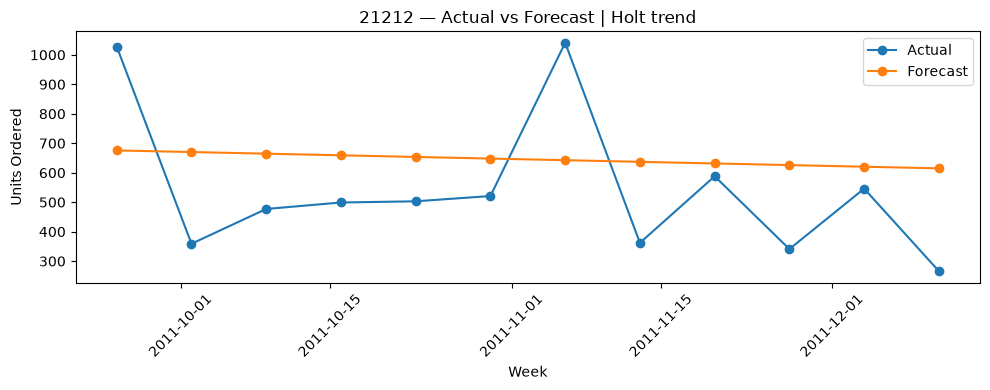

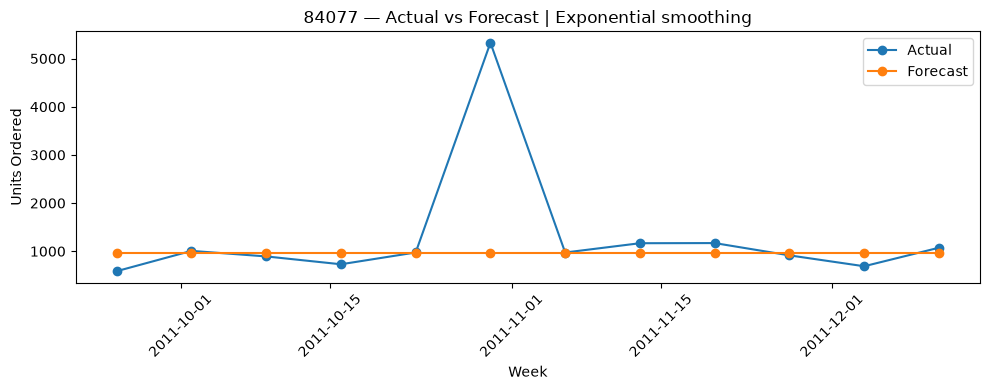

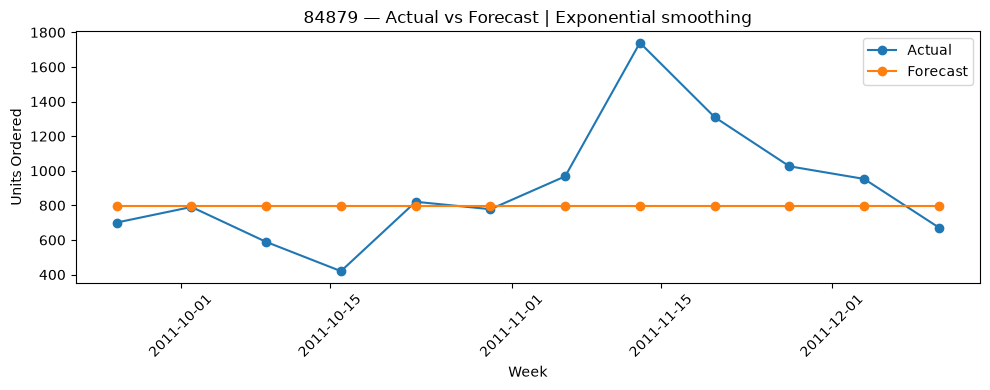

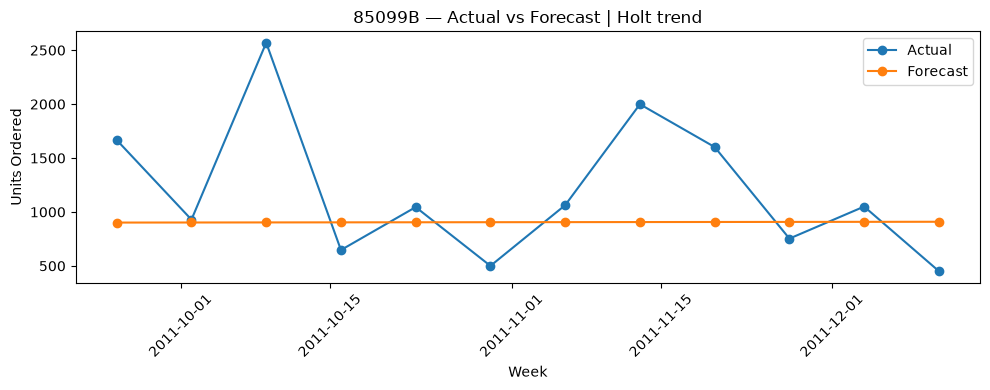

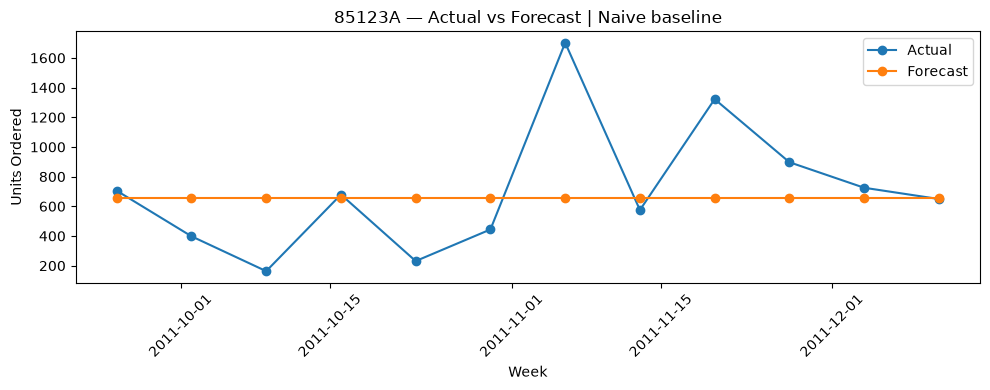

In [60]:
for stock_code in final_forecast_results["stock_code"].unique():

    product_data = final_forecast_results[
        final_forecast_results["stock_code"] == stock_code
    ].sort_values("invoice_date")

    best_model = best_model_map[stock_code]

    plt.figure(figsize=(10, 4))

    plt.plot(
        product_data["invoice_date"],
        product_data["weekly_demand"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        product_data["invoice_date"],
        product_data["final_forecast"],
        marker="o",
        label="Forecast"
    )

    plt.title(
        f"{stock_code} — Actual vs Forecast | {best_model}"
    )
    plt.xlabel("Week")
    plt.ylabel("Units Ordered")

    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Forecast Review

The winning models generally capture the underlying weekly demand level, but forecast accuracy varies by product.

Large one-off spikes remain difficult to predict, particularly for `84077` and `85099B`. Products with more stable demand, such as `84879`, are forecast more accurately.

The charts also support the model comparison results: different products require different forecasting approaches, and even the best model may struggle with sudden short-term demand surges.

In [64]:
final_model_summary = model_comparison[
    [
        "stock_code",
        "best_model",
        "baseline_WMAPE",
        "moving_avg_WMAPE",
        "seasonal_WMAPE",
        "exp_smoothing_WMAPE",
        "holt_WMAPE"
    ]
].copy()

final_model_summary["best_WMAPE"] = (
    final_model_summary[
        [
            "baseline_WMAPE",
            "moving_avg_WMAPE",
            "seasonal_WMAPE",
            "exp_smoothing_WMAPE",
            "holt_WMAPE"
        ]
    ]
    .min(axis=1)
)
final_model_summary["best_WMAPE"] = (
    final_model_summary["best_WMAPE"]
    .round(2)
)
final_model_summary[
    ["stock_code", "best_model", "best_WMAPE"]
]



,stock_code,best_model,best_WMAPE
0,21212,Holt trend,41.55
1,84077,Exponential smoothing,38.40
2,84879,Exponential smoothing,26.62
3,85099B,Holt trend,41.75
4,85123A,Naive baseline,42.05


## Modelling Summary

Five forecasting approaches were compared across the selected products:

- naive baseline
- four-week moving average
- seasonal naive
- simple exponential smoothing
- Holt's trend method

Model performance was evaluated using MAE, RMSE and WMAPE, with WMAPE used as the main model-selection metric.

The best-performing model differed by product:

- `21212` — Holt trend
- `84077` — Exponential smoothing
- `84879` — Exponential smoothing
- `85099B` — Holt trend
- `85123A` — Naive baseline

The results show that a single forecasting method does not perform best across every SKU. Products with more stable demand were generally easier to forecast, while products with larger weekly spikes produced higher forecast error.

The final forecasting approach will therefore use the best-performing model for each product.

In [65]:
MODEL_OUTPUT = DATA_PROCESSED / "model_summary.csv"
FORECAST_OUTPUT = DATA_PROCESSED / "final_forecast_results.csv"

final_model_summary.to_csv(
    MODEL_OUTPUT,
    index=False
)

final_forecast_results.to_csv(
    FORECAST_OUTPUT,
    index=False
)

print(f"Saved model summary to: {MODEL_OUTPUT}")
print(f"Saved forecast results to: {FORECAST_OUTPUT}")

Saved model summary to: ..\data\processed\model_summary.csv
Saved forecast results to: ..\data\processed\final_forecast_results.csv
